## Project environment

In [73]:
# Importing libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Project folder directory
os.chdir("C:/GitHub/SupplierSegmentation-Clustering") # Main project folder
processed_dir = Path('data/processed') # Location processed data file

## Load processed (aggregated) data

In [74]:
aggregated_data = "aggregated_supplier_df.parquet" # Aggregated data filename
agg_df = pd.read_parquet(processed_dir / aggregated_data) # Read Parquet file

## Feature selection and scaling

In [75]:
# Selecting model features
features = ["total_spend_log", "total_invoices_log", "avg_invoice_amount"]
X_agg = agg_df[features].copy()

# Apply scaling to standardize feature values
scaler = StandardScaler()
agg_scaled = scaler.fit_transform(X_agg)

## Model parameters

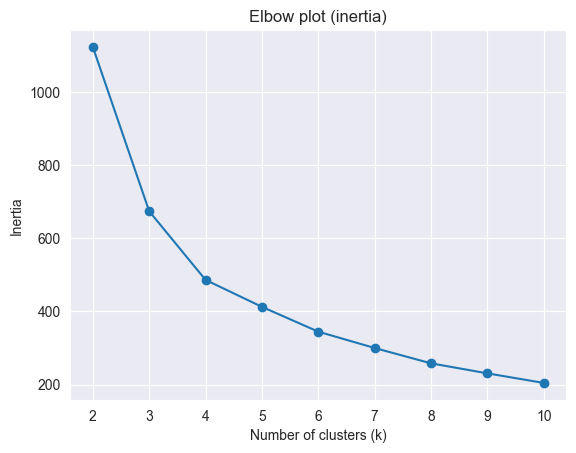

In [76]:
# Apply Elbow method for selecting number of clusters
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=26)
    kmeans.fit(agg_scaled)
    inertia.append(kmeans.inertia_)

# Visualize Elbow output
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow plot (inertia)")
plt.show()

## Run k-means clustering

In [77]:
# Run k-means with k clusters
k = 3
kmeans = KMeans(
    n_clusters=k,
    random_state=26
)
agg_df['cluster'] = kmeans.fit_predict(agg_scaled)

# Add cluster labels to the df
cluster_labels = {
    2: "Strategic suppliers",
    0: "High-value suppliers",
    1: "Tail suppliers"
}
agg_df['cluster_label'] = agg_df['cluster'].map(cluster_labels)

## Validation

In [78]:
# Silhouette score
score = silhouette_score(agg_scaled, agg_df["cluster"])
print("Silhouette score:", round(score, 3))

# Summary table
cluster_summary = (
    agg_df
    .groupby("cluster_label")
    .agg(
        suppliers=("supplier_id", "count"),
        total_spend=("total_spend", "sum"),
        total_spend_median=("total_spend", "median"),
        total_invoices=("total_invoices", "sum")
    )
    .round(0)
    .sort_values("total_spend", ascending=False)
)
cluster_summary

Silhouette score: 0.446


,suppliers,total_spend,total_spend_median,total_invoices
cluster_label,,,,
High-value suppliers,243,93462042.0,76885.0,567
Strategic suppliers,76,23362233.0,90654.0,4030
Tail suppliers,297,2051993.0,4977.0,672


## Export results

In [80]:
# Export to CSV
output_file = "supplier_segmentation.csv"
agg_df.to_csv(processed_dir / output_file)

In [84]:
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   supplier_id         616 non-null    int64  
 1   supplier_name       616 non-null    object 
 2   total_spend         616 non-null    float64
 3   avg_invoice_amount  616 non-null    float64
 4   total_invoices      616 non-null    int64  
 5   total_spend_log     616 non-null    float64
 6   total_invoices_log  616 non-null    float64
 7   cluster             616 non-null    int32  
 8   cluster_label       616 non-null    object 
dtypes: float64(4), int32(1), int64(2), object(2)
memory usage: 41.0+ KB


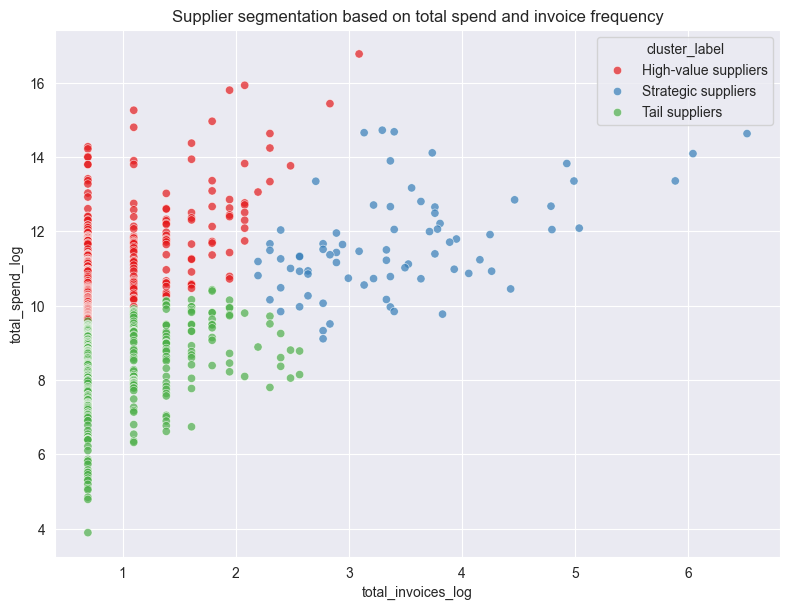

In [86]:
# Visualize supplier clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agg_df,
    x="total_invoices_log",
    y="total_spend_log",
    hue="cluster_label",
    palette="Set1",
    alpha=0.7
)
plt.tight_layout()
plt.title("Supplier segmentation based on total spend and invoice frequency")
plt.show()